# Visualization LA County Hospitals with Population Density
Visualizes 165 hospitals overlaid on the 272 LA County neighborhood polygons, with resident population and population density by neighborhood.

## Step 1 — Imports

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.ops import unary_union

print("Ready.")

Ready.


## Step 2 — Load Data

In [55]:
la_county = gpd.read_file("../../data/la_county.geojson").set_crs("EPSG:4326", allow_override=True)
hospitals  = gpd.read_file("../../data/hospitals.geojson").set_crs("EPSG:4326", allow_override=True)
tracts = gpd.read_file("../../data/svi_tracts.geojson").set_crs("EPSG:4326", allow_override=True)

print(f"Neighborhoods : {len(la_county)}")
print(f"Hospitals     : {len(hospitals)}")
print(f"Tracts        : {len(tracts)}")
hospitals.head()

Neighborhoods : 272
Hospitals     : 165
Tracts        : 2493


,objectid,name,city,geometry
0,9,Verdugo Hills Hospital,Glendale,POINT (-118.21602 34.20453)
1,11,Barlow Respiratory Hospital - Los Angeles (Mai...,Los Angeles,POINT (-118.24831 34.07569)
2,20,Glendora Community Hospital,Glendora,POINT (-117.86507 34.12731)
3,25,Providence Little Company Of Mary Medical Cent...,Torrance,POINT (-118.35711 33.83863)
4,35,Glendale Memorial Hospital And Health Center,Glendale,POINT (-118.25744 34.12806)


## Step 3 — Assign Each Hospital to a Neighborhood based on neighborhood boundary

Tags every hospital point with the neighborhood it falls inside.
Hospitals that fall outside all neighborhood polygons get `neighborhood = None`.

In [56]:
hospitals_joined = gpd.sjoin(
    hospitals,
    la_county[["name", "geometry"]],
    how="left",
    predicate="within"
).rename(columns={"name_right": "neighborhood"})

# Count hospitals per neighborhood
hosp_per_hood = (
    hospitals_joined.groupby("neighborhood")   # fix 1: was "city"
    .size()
    .reset_index(name="hospital_count")
)

la_county = la_county.merge(
    hosp_per_hood,
    left_on="name",         # fix 2: explicit left/right keys
    right_on="neighborhood",
    how="left"
)
la_county["hospital_count"] = la_county["hospital_count"].fillna(0).astype(int)

n_covered = (la_county["hospital_count"] > 0).sum()
n_none    = (la_county["hospital_count"] == 0).sum()
n_outside = hospitals_joined["neighborhood"].isna().sum()

print(f"Neighborhoods WITH at least 1 hospital : {n_covered}")
print(f"Neighborhoods with NO hospital         : {n_none}")
print(f"Hospitals outside named neighborhoods  : {n_outside}")

Neighborhoods WITH at least 1 hospital : 70
Neighborhoods with NO hospital         : 202
Hospitals outside named neighborhoods  : 3


## Step 4 — Map: Hospitals on LA County Neighborhoods

Neighborhoods are colored by hospital count.
Red dots = hospital locations.

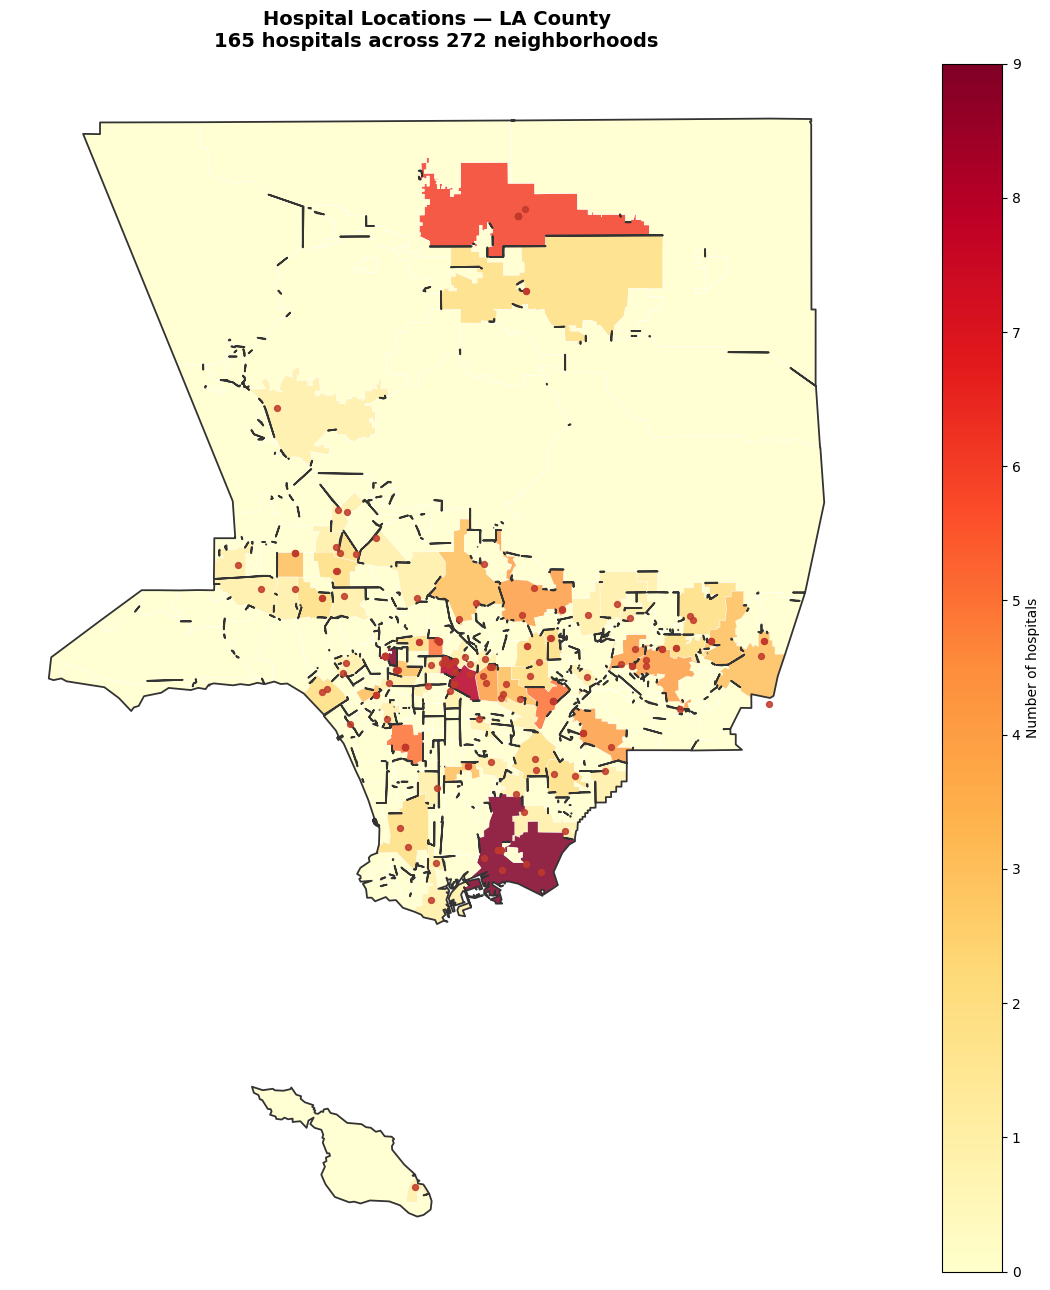

In [57]:
fig, ax = plt.subplots(figsize=(16, 13))

# ── Neighborhood choropleth ──
la_county.plot(
    column="hospital_count",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.85,
    legend=True,
    legend_kwds={
        "label": "Number of hospitals",   # fix 1: removed shrink/pad
    }
)

# ── County boundary outline ──
gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

# ── Hospital points ──
hospitals.plot(
    ax=ax,
    color="#c0392b",
    markersize=18,
    alpha=0.85,
    zorder=5,
    label="Hospital"
)


ax.set_title(
    f"Hospital Locations — LA County\n"          
    f"{len(hospitals)} hospitals across {len(la_county)} neighborhoods",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Step 5 — Highlight Neighborhoods with No Hospitals

These are the neighborhoods with zero hospitals

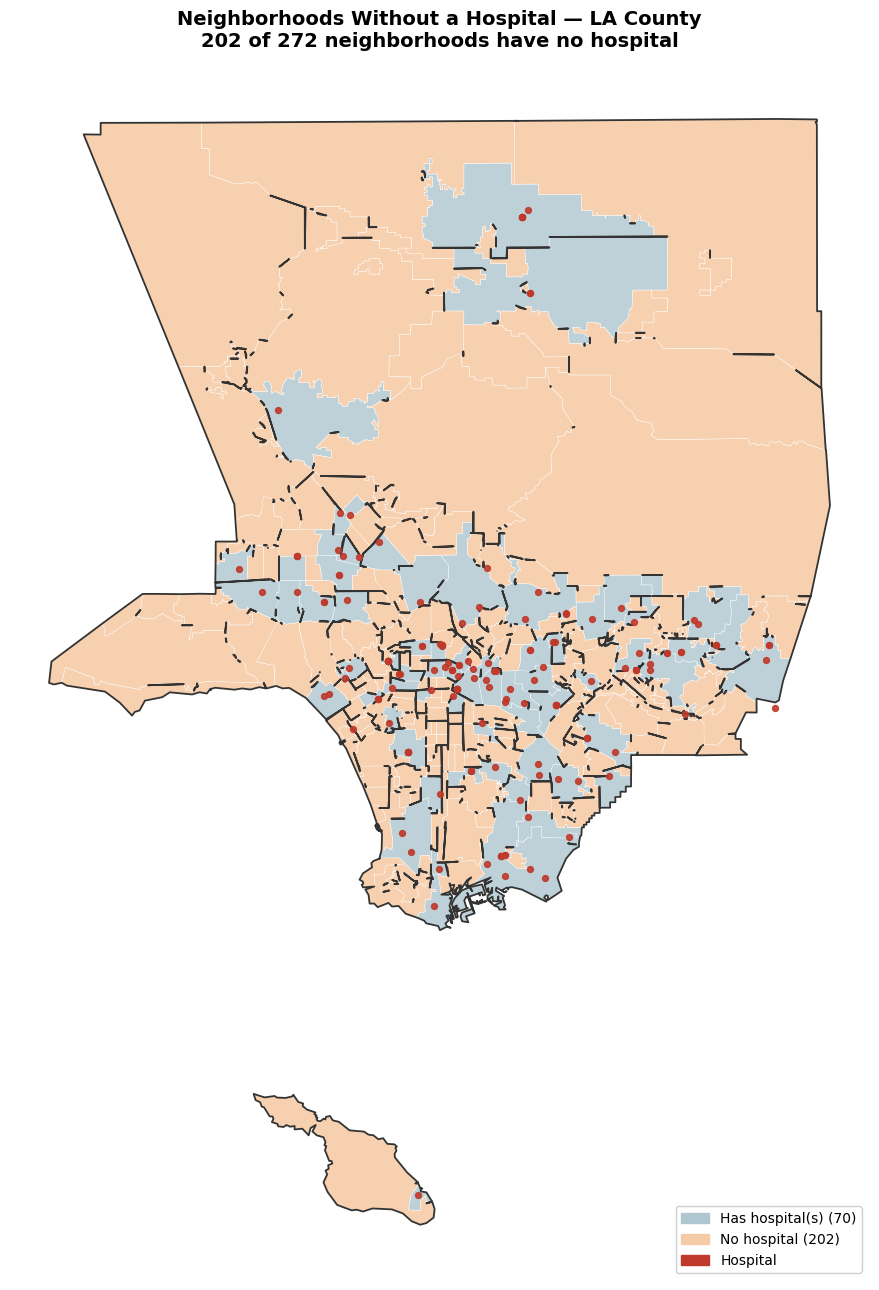

In [58]:
no_hospital = la_county[la_county["hospital_count"] == 0].copy()
has_hospital = la_county[la_county["hospital_count"] > 0].copy()

fig, ax = plt.subplots(figsize=(16, 13))

has_hospital.plot(
    ax=ax, color="#aec6cf", edgecolor="white", linewidth=0.35, alpha=0.80
)
no_hospital.plot(
    ax=ax, color="#f5cba7", edgecolor="white", linewidth=0.35, alpha=0.90
)

gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

hospitals.plot(
    ax=ax, color="#c0392b", markersize=18, alpha=0.90, zorder=5
)

patches = [
    mpatches.Patch(color="#aec6cf",
                   label=f"Has hospital(s) ({len(has_hospital)})"),
    mpatches.Patch(color="#f5cba7",
                   label=f"No hospital ({len(no_hospital)})"),
    mpatches.Patch(color="#c0392b", label="Hospital"),
]
ax.legend(handles=patches, fontsize=10, loc="lower right", framealpha=0.92)

ax.set_title(
    f"Neighborhoods Without a Hospital — LA County\n"         # fix 2: \n instead of raw newline
    f"{len(no_hospital)} of {len(la_county)} neighborhoods have no hospital",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Step 6 — Add Population and Population Density by Neighborhood

Uses the SVI census-tract layer (`svi_tracts.geojson`) to aggregate resident
population (`e_totpop`) into each LA County neighborhood.  
Each tract centroid is assigned to exactly one neighborhood to avoid
double-counting tracts that straddle boundaries.  
Population density is then expressed as **residents per km²**.

In [59]:
# ── Compute neighborhood area (needs projected CRS) ──
la_utm = la_county.to_crs("EPSG:32611")
la_county["area_km2"]        = (la_utm.geometry.area / 1e6).round(3)
la_county["density_per_km2"] = (la_county["hospital_count"] / la_county["area_km2"]).round(5)

# ── Use tract centroids for clean point-in-polygon assignment ──
# Project to UTM first to suppress geographic CRS centroid warning
tracts_utm = tracts.to_crs("EPSG:32611")
tracts_centroids = tracts_utm.copy()
tracts_centroids["geometry"] = tracts_utm.geometry.centroid
tracts_centroids = tracts_centroids.to_crs("EPSG:4326")  # back to WGS84 for sjoin

# Spatial join: assign each tract centroid to a neighborhood
tracts_joined = gpd.sjoin(
    tracts_centroids[["e_totpop", "geometry"]],
    la_county[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Aggregate population per neighborhood
pop_per_hood = (
    tracts_joined.groupby("name")["e_totpop"]
    .sum()
    .reset_index()
    .rename(columns={"e_totpop": "population"})
)

# Merge back into la_county
la_county = la_county.merge(pop_per_hood, on="name", how="left")
la_county["population"]          = la_county["population"].fillna(0).astype(int)
la_county["pop_density_per_km2"] = (la_county["population"] / la_county["area_km2"]).round(1)

total_pop = la_county["population"].sum()
print(f"Total LA County population mapped : {total_pop:,}")
print(f"Tracts matched to a neighborhood  : {tracts_joined['name'].notna().sum()} / {len(tracts_joined)}")
la_county[["name", "population", "area_km2", "pop_density_per_km2"]].sort_values(
    "population", ascending=False
).head(10)

Total LA County population mapped : 10,014,399
Tracts matched to a neighborhood  : 2488 / 2496


,name,population,area_km2,pop_density_per_km2
135,Long Beach,441922,134.744,3279.7
83,Glendale,199357,79.123,2519.6
196,Santa Clarita,185727,148.915,1247.2
124,Lancaster,163159,264.893,615.9
165,Palmdale,161950,347.555,466.0
176,Pomona,153480,59.569,2576.5
225,Torrance,144430,53.448,2702.3
170,Pasadena,143781,65.560,2193.1
66,East Los Angeles,117839,19.246,6122.8
257,Westlake,115022,6.920,16621.7


## Step 7 — Combined Summary Table (hospitals + population)

In [60]:
full_summary = (
    la_county[la_county["hospital_count"] > 0]
    [[
        "name",
        "hospital_count",
        "density_per_km2",
        "population",
        "pop_density_per_km2",
        "area_km2",
    ]]
    .sort_values("hospital_count", ascending=False)
    .reset_index(drop=True)
)
full_summary.index += 1
full_summary.columns = [
    "Neighborhood",
    "Hospitals",
    "Hospitals/km²",
    "Population",
    "Residents/km²",
    "Area (km²)",
]

print(f"LA County total mapped population : {la_county['population'].sum():,}")
print(f"Mean residents/km² (all hoods)    : {la_county['pop_density_per_km2'].mean():,.1f}")
print(f"Max residents/km²                 : {la_county['pop_density_per_km2'].max():,.1f}  ({la_county.loc[la_county['pop_density_per_km2'].idxmax(), 'name']})")
print()
print("Top 20 neighborhoods by hospital count (with population):")
full_summary.head(20)

LA County total mapped population : 10,014,399
Mean residents/km² (all hoods)    : 3,319.7
Max residents/km²                 : 16,621.7  (Westlake)

Top 20 neighborhoods by hospital count (with population):


,Neighborhood,Hospitals,Hospitals/km²,Population,Residents/km²,Area (km²)
1,Long Beach,9,0.06679,441922,3279.7,134.744
2,Beverly Grove,9,2.14337,21263,5063.8,4.199
3,Westlake,8,1.15607,115022,16621.7,6.920
4,Downtown,8,0.53444,53284,3559.6,14.969
5,Lancaster,6,0.02265,163159,615.9,264.893
6,Inglewood,5,0.21314,101355,4320.5,23.459
7,Montebello,5,0.22981,64619,2970.0,21.757
8,East Hollywood,5,0.81169,65393,10615.7,6.160
9,Boyle Heights,4,0.23366,95798,5596.0,17.119
10,Whittier,4,0.10476,84189,2205.0,38.181


## Step 8 — Map: Population Density with Hospital Locations

Neighborhoods colored by resident population density (residents per km²).
Dark dots = hospital locations, showing how hospital coverage relates to dense areas.

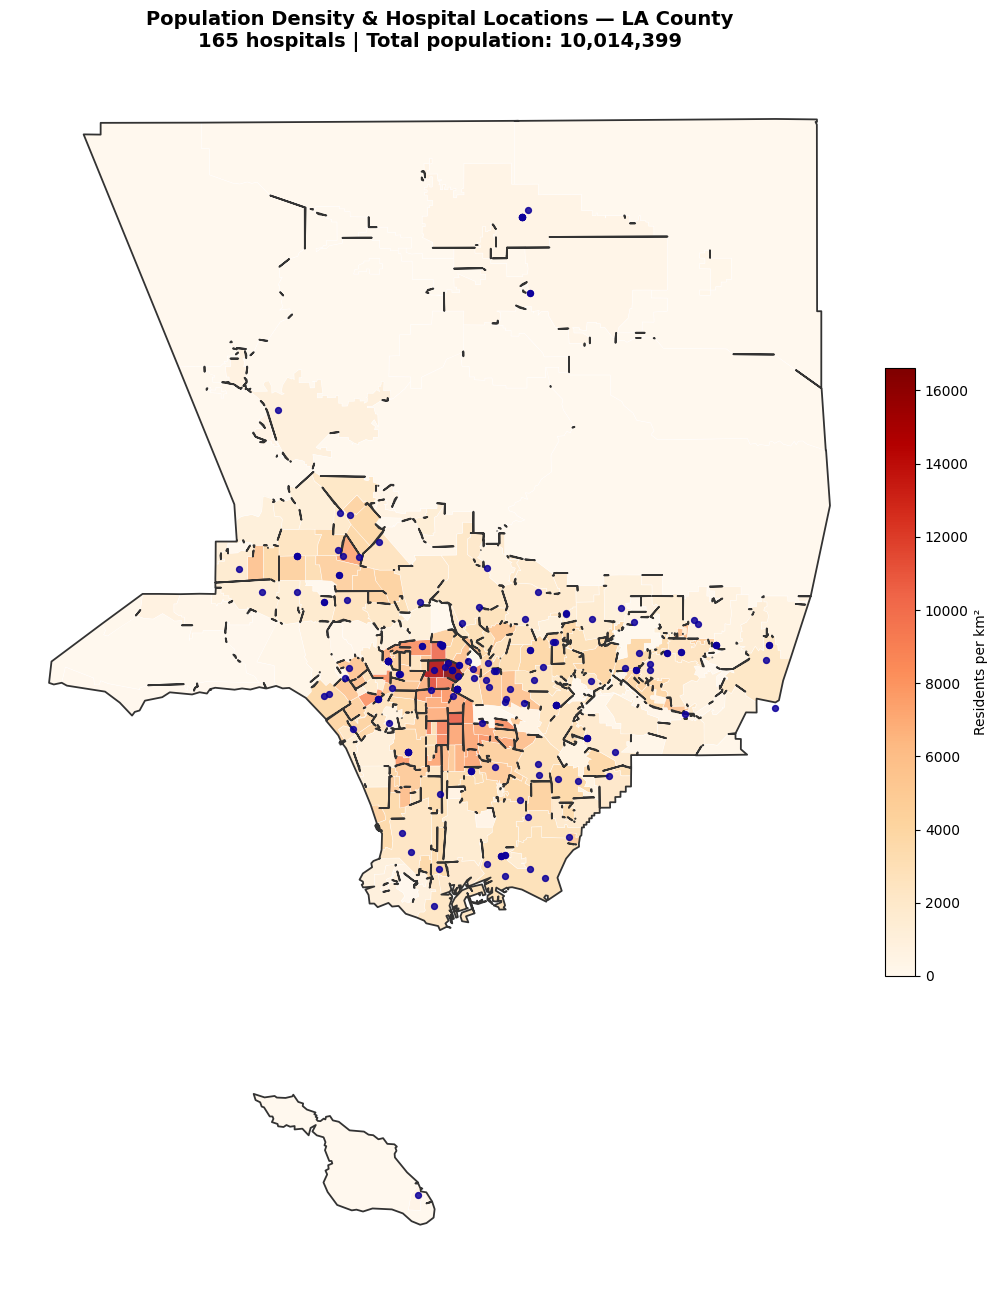

In [61]:
fig, ax = plt.subplots(figsize=(16, 13))

la_county.plot(
    column="pop_density_per_km2",
    ax=ax,
    cmap="OrRd",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.85,
    legend=True,
    legend_kwds={"label": "Residents per km²", "shrink": 0.5, "pad": 0.01},
)

gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

hospitals.plot(
    ax=ax, color="#0d009b", markersize=18, alpha=0.85, zorder=5, label="Hospital"
)

ax.set_title(
    f"Population Density & Hospital Locations — LA County\n"
    f"{len(hospitals)} hospitals | Total population: {la_county['population'].sum():,}",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()